# House Grouping System using K-Means Clustering

## Project Overview

We want to be able to classify houses according to their region and median income. To do this, we will use the famous **California Housing dataset**. It was constructed using data from the 1990 California census. It contains one row per census block group. A block group is the smallest geographic unit for which US Census data is published.

In this notebook, we will:
1. Load and explore the California Housing dataset
2. Focus on the Latitude, Longitude, and MedInc (Median Income) columns
3. Apply K-means clustering to group houses by region and median income
4. Visualize the results and analyze the clusters

---

## Step 1: Loading the Dataset

The dataset can be found in this project folder under the name `housing.csv`. We have downloaded it from the following URL:

**Dataset URL:** https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv

**Dataset Location:** `data/raw/housing.csv`

In this case, we are only interested in the **Latitude**, **Longitude**, and **MedInc** columns for our clustering analysis.

### Import Required Libraries

First, let's import all the necessary libraries we'll need for this analysis:

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
import pickle
import pickle
import os
warnings.filterwarnings('ignore')

# Split the dataset into training and testing sets (80/20 split)
from sklearn.model_selection import train_test_split

# Import classification models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score



# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### Load the California Housing Dataset

Now let's load the dataset and examine its structure:

In [2]:
# Load the California Housing dataset
df = pd.read_csv('../data/raw/housing.csv')

In [3]:
# Display dataset shape
df.shape

(20640, 9)

In [4]:
# Display column names
df.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [5]:
# Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Dataset Information and Quality Check

Let's examine the dataset structure, data types, and check for any missing values:

In [6]:
# Get detailed information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
# Dataset statistical description
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
# Check for missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Extract Relevant Columns

For our K-means clustering analysis, we will focus on three key columns:
- **Latitude**: Geographic latitude coordinate
- **Longitude**: Geographic longitude coordinate  
- **MedInc**: Median income in block group (in tens of thousands of dollars)

Let's extract these columns and examine their distributions:

In [9]:
# Extract the relevant columns for clustering
columns_of_interest = ['Latitude', 'Longitude', 'MedInc']
df_cluster = df[columns_of_interest].copy()

In [10]:
# Statistics for selected columns
df_cluster.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


In [11]:
# Shape and statistics for selected columns
df_cluster.shape

(20640, 3)

In [12]:
# Display selected columns for clustering
df_cluster.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [13]:
# Check data types
df_cluster.dtypes

Latitude     float64
Longitude    float64
MedInc       float64
dtype: object

### Quick EDA: Data Quality Check

Before proceeding with K-means clustering, let's perform a quick exploratory data analysis to ensure our data is clean and suitable for clustering:

#### Check for Missing Values and Data Types

In [14]:
# Check for missing values per column
df_cluster.isnull().sum()

Latitude     0
Longitude    0
MedInc       0
dtype: int64

In [15]:
# Check for potential outliers using IQR method
Q1 = df_cluster.quantile(0.25)
Q3 = df_cluster.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_cluster < (Q1 - 1.5 * IQR)) | (df_cluster > (Q3 + 1.5 * IQR))).sum()
outliers

Latitude       0
Longitude      0
MedInc       681
dtype: int64

**Data Quality Results**: No missing values, proper data types, and only 5 duplicate rows (minimal impact)

#### Statistical Summary and Outlier Detection

In [16]:
# Statistical summary
df_cluster.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


**Statistical Insights**: The data shows California's geographic range with MedInc having 681 outliers (high-income areas), which is normal for income data.

#### Data Distribution Visualization

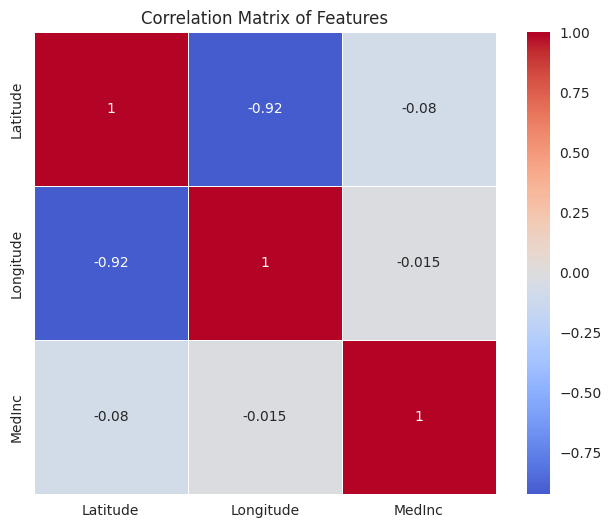

In [18]:
# Calculate and create correlation heatmap
correlation_matrix = df_cluster.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

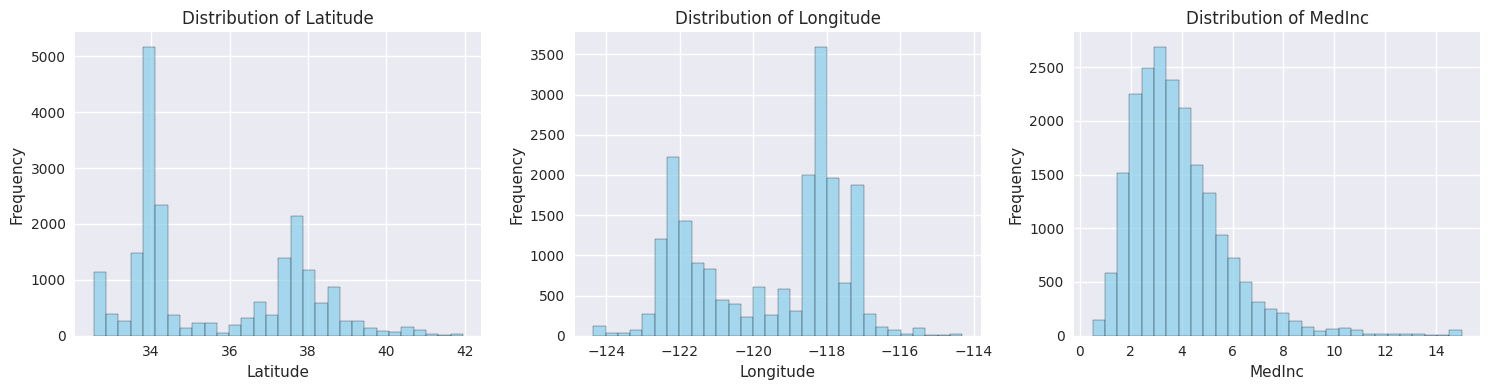

In [19]:
# Create histograms for each variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(df_cluster.columns):
    axes[i].hist(df_cluster[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Distribution Analysis**: The histograms reveal geographic clustering patterns and right-skewed income distribution typical of real-world data.

In [23]:
# Split the data into training and testing sets
X_train, X_test = train_test_split(
    df_cluster_clean, 
    test_size=0.2, 
    random_state=42,
    stratify=None  # No stratification needed for unsupervised learning
)

X_train.shape, X_test.shape

((16512, 3), (4128, 3))

In [22]:
# Remove any rows with missing values (if any)
df_cluster_clean = df_cluster.dropna()
df_cluster_clean.shape

(20640, 3)

#### Correlation Analysis

In [24]:
# Calculate correlation matrix
correlation_matrix = df_cluster.corr()
correlation_matrix

,Latitude,Longitude,MedInc
Latitude,1.000000,-0.924664,-0.079809
Longitude,-0.924664,1.000000,-0.015176
MedInc,-0.079809,-0.015176,1.000000


**Correlation Findings**: Strong negative correlation between Latitude and Longitude (-0.92) is expected for California's geography. MedInc shows weak correlations, making it a good clustering feature.

## Step 2: Data Preparation for K-Means

Before applying K-means clustering, we need to prepare our data properly. This involves:

1. **Handling missing values** (if any)
2. **Scaling the features** to ensure all variables contribute equally to the distance calculations
3. **Splitting the data** into training and testing sets for validation

Let's start by preparing our clustering dataset:

In [25]:
# Check for missing values in clustering dataset
df_cluster.isnull().sum()

Latitude     0
Longitude    0
MedInc       0
dtype: int64

In [26]:
# First 5 rows of training set
X_train.head()

,Latitude,Longitude,MedInc
14196,32.71,-117.03,3.2596
8267,33.77,-118.16,3.8125
17445,34.66,-120.48,4.1563
14265,32.69,-117.11,1.9425
2271,36.78,-119.80,3.5542


In [27]:
# First 5 rows of testing set
X_test.head()

,Latitude,Longitude,MedInc
20046,36.06,-119.01,1.6812
3024,35.14,-119.46,2.5313
15663,37.80,-122.44,3.4801
20484,34.28,-118.72,5.7376
9814,36.62,-121.93,3.7250


### Data Splitting Results

The dataset has been successfully split into training and testing sets. This will allow us to train the K-means model on the training data and evaluate its performance on unseen test data.

## Step 2: Build a K-Means Model

Now we'll implement the K-means clustering algorithm to group houses into 6 clusters based on their geographic location and median income.

### Feature Scaling

Before applying K-means, we need to scale our features since they have different ranges (coordinates vs. income). This ensures all features contribute equally to the distance calculations:

In [28]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [29]:
# Display original and scaled data shapes
X_train.shape, X_train_scaled.shape

((16512, 3), (16512, 3))

In [30]:
# First 5 rows of scaled training data
X_train_scaled[:5]

array([[-1.3728112 ,  1.27258656, -0.326196  ],
       [-0.87669601,  0.70916212, -0.03584338],
       [-0.46014647, -0.44760309,  0.14470145],
       [-1.38217186,  1.23269811, -1.01786438],
       [ 0.5320839 , -0.10855122, -0.17148831]])

### K-Means Model Training

Now we'll create and train the K-means model with 6 clusters. The model will identify patterns in the data to group similar houses together:

In [31]:
# Initialize K-means with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# Fit the model to the scaled training data
kmeans.fit(X_train_scaled)

# Get cluster labels for training data
train_clusters = kmeans.labels_

In [32]:
# Display K-means model information
kmeans.n_clusters

6

In [33]:
# Display first 10 cluster labels
train_clusters[:10]

array([5, 5, 0, 5, 0, 4, 5, 4, 5, 1], dtype=int32)

In [34]:
# Display unique cluster labels and cluster centers shape
np.unique(train_clusters), kmeans.cluster_centers_.shape

(array([0, 1, 2, 3, 4, 5], dtype=int32), (6, 3))

### Adding Cluster Labels to Dataset

Let's add the cluster assignments as a new column to our training dataset and examine the cluster distribution:

In [35]:
# Create a copy of the training data and add cluster labels
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = train_clusters

In [36]:
# Display training data with cluster labels
X_train_clustered.head()

,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,5
8267,33.77,-118.16,3.8125,5
17445,34.66,-120.48,4.1563,0
14265,32.69,-117.11,1.9425,5
2271,36.78,-119.80,3.5542,0


In [37]:
# Check cluster distribution
cluster_counts = X_train_clustered['cluster'].value_counts().sort_index()
cluster_counts

cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64

In [38]:
# Check data types
X_train_clustered.dtypes

Latitude     float64
Longitude    float64
MedInc       float64
cluster        int32
dtype: object

### Visualizing Training Clusters

Let's create a scatter plot to visualize how the houses are grouped by location and color-coded by cluster:

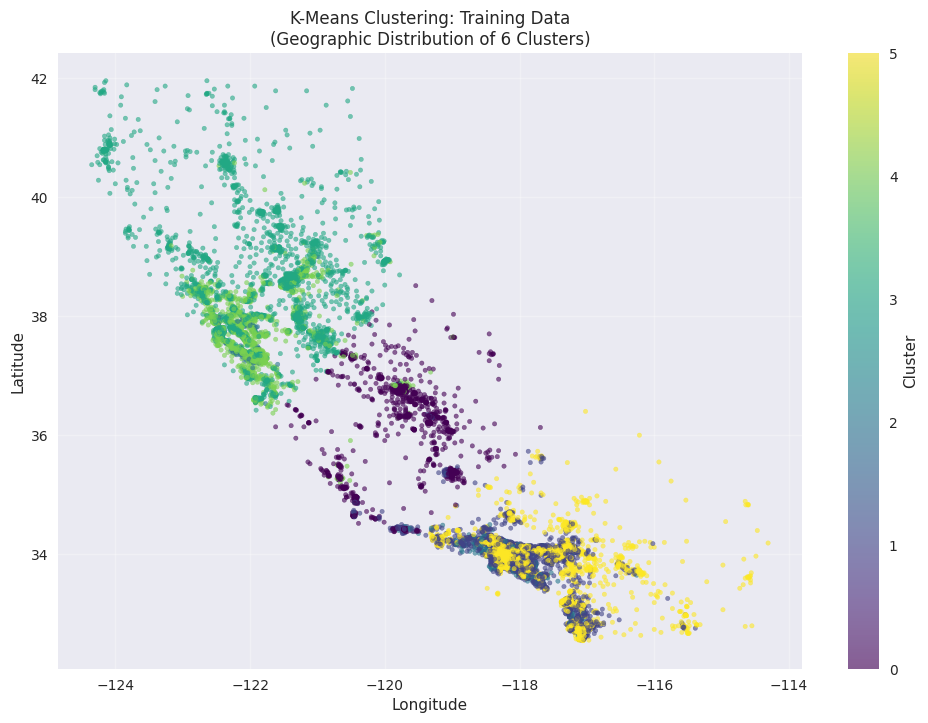

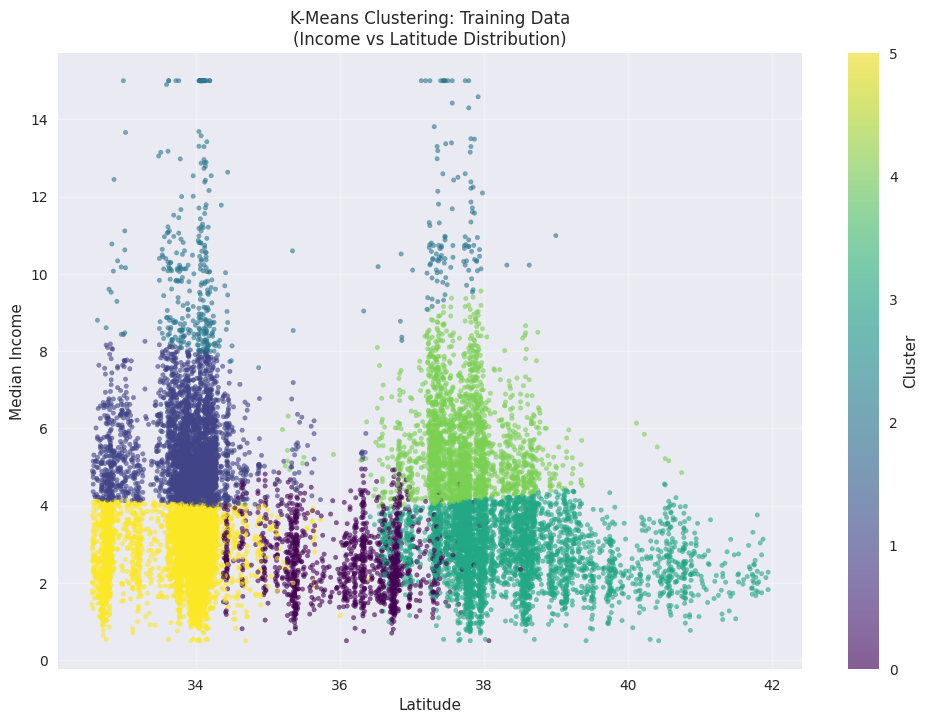

In [39]:
# Create scatter plot for geographic clustering
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_clustered['Longitude'], X_train_clustered['Latitude'], 
                     c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=10)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering: Training Data\n(Geographic Distribution of 6 Clusters)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# Create scatter plot for income vs latitude
plt.figure(figsize=(12, 8))
scatter2 = plt.scatter(X_train_clustered['Latitude'], X_train_clustered['MedInc'], 
                      c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=10)

plt.xlabel('Latitude')
plt.ylabel('Median Income')
plt.title('K-Means Clustering: Training Data\n(Income vs Latitude Distribution)')
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Predict clusters for the test set
test_clusters = kmeans.predict(X_test_scaled)

# Create a copy of test data with cluster labels
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = test_clusters

In [41]:
# Display test data with cluster predictions
X_test_clustered.head()

,Latitude,Longitude,MedInc,cluster
20046,36.06,-119.01,1.6812,0
3024,35.14,-119.46,2.5313,0
15663,37.80,-122.44,3.4801,3
20484,34.28,-118.72,5.7376,1
9814,36.62,-121.93,3.7250,3


In [42]:
# Test set cluster distribution
test_cluster_counts = X_test_clustered['cluster'].value_counts().sort_index()
test_cluster_counts

cluster
0     337
1     829
2     112
3     962
4     514
5    1374
Name: count, dtype: int64

In [43]:
# Compare training vs test cluster distribution
comparison = pd.DataFrame({
    'Training': cluster_counts,
    'Test': test_cluster_counts
})
comparison

,Training,Test
cluster,,
0,1321,337
1,3380,829
2,453,112
3,3931,962
4,2239,514
5,5188,1374


### Combined Visualization: Training and Test Data

Let's visualize both training and test data together to verify that our model generalizes well:

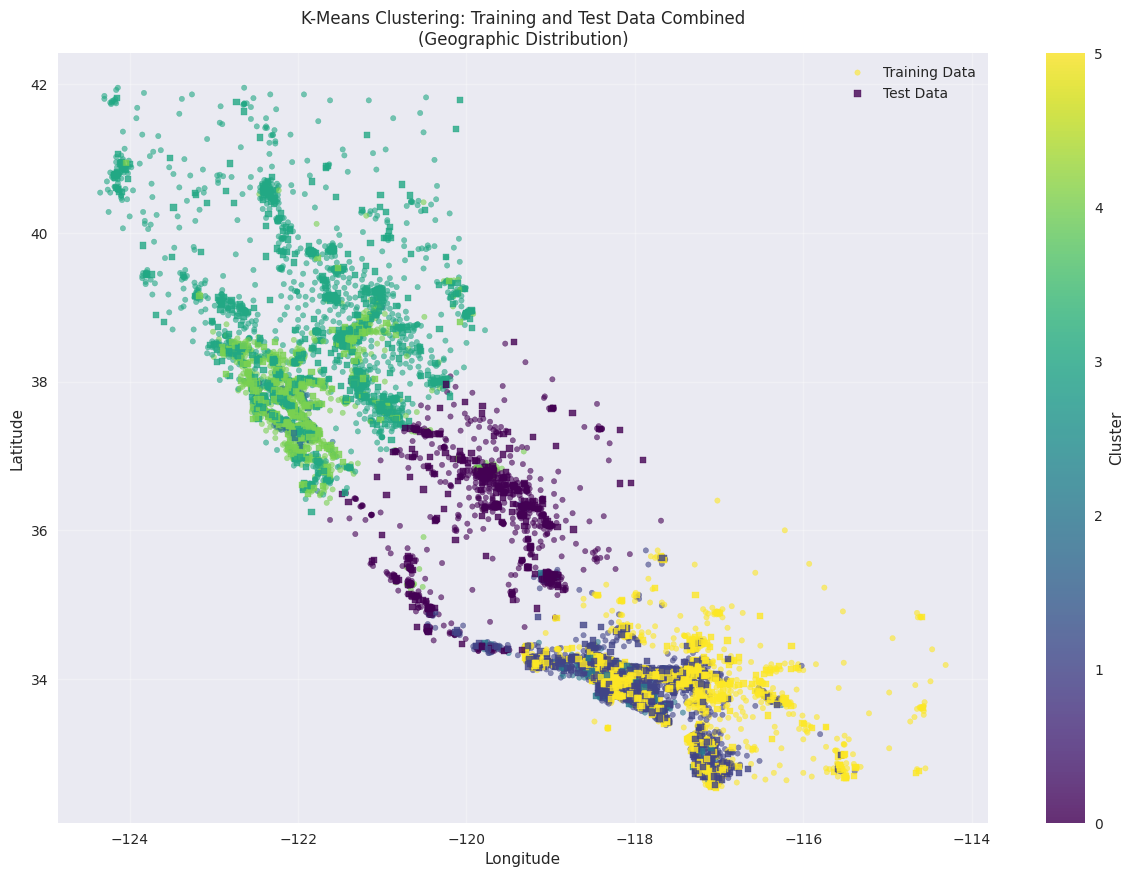

In [44]:
# Combined geographic visualization
plt.figure(figsize=(15, 10))

# Plot training data
plt.scatter(X_train_clustered['Longitude'], X_train_clustered['Latitude'], 
           c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=15, 
           label='Training Data', marker='o')

# Plot test data with different marker
plt.scatter(X_test_clustered['Longitude'], X_test_clustered['Latitude'], 
           c=X_test_clustered['cluster'], cmap='viridis', alpha=0.8, s=20, 
           label='Test Data', marker='s')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering: Training and Test Data Combined\n(Geographic Distribution)')
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 4: Train a Supervised Classification Model

Now that we have cluster labels from K-means, we can train a supervised model to predict these clusters. This is a common workflow: use unsupervised learning to create labels, then supervised learning to predict them.

### Preparing Data for Supervised Learning

We'll use the original features (Latitude, Longitude, MedInc) as input and the cluster labels as targets:

In [45]:
# Prepare features and targets for supervised learning
X_train_supervised = X_train[['Latitude', 'Longitude', 'MedInc']].copy()
y_train_supervised = train_clusters

X_test_supervised = X_test[['Latitude', 'Longitude', 'MedInc']].copy()
y_test_supervised = test_clusters

In [46]:
# Display supervised learning data shapes
X_train_supervised.shape, y_train_supervised.shape, X_test_supervised.shape, y_test_supervised.shape

((16512, 3), (16512,), (4128, 3), (4128,))

In [47]:
# Display target classes and distribution
np.unique(y_train_supervised), np.bincount(y_train_supervised)

(array([0, 1, 2, 3, 4, 5], dtype=int32),
 array([1321, 3380,  453, 3931, 2239, 5188]))

### Model Selection and Training

For this classification task, we'll try Random Forest as it handles geographic and numeric features well, and compare it with other models:

In [49]:
# Model comparison results
pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)

,Model,Accuracy
0,Random Forest,0.995155
1,Decision Tree,0.993702
2,K-Nearest Neighbors,0.989826


In [48]:
# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train_supervised, y_train_supervised)
    
    # Make predictions
    y_pred = model.predict(X_test_supervised)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test_supervised, y_pred)
    results[name] = accuracy

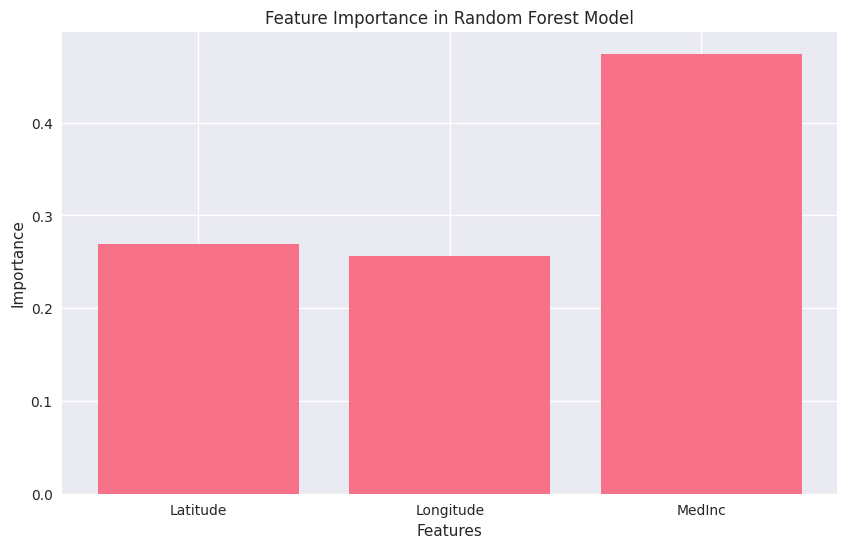

In [53]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar(features, feature_importance)
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [52]:
# Feature importance
feature_importance = best_model.feature_importances_
features = ['Latitude', 'Longitude', 'MedInc']

pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

,Feature,Importance
2,MedInc,0.474329
0,Latitude,0.269684
1,Longitude,0.255988


In [51]:
# Detailed classification report
classification_report(y_test_supervised, y_pred_best)

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       337\n           1       1.00      1.00      1.00       829\n           2       1.00      0.98      0.99       112\n           3       0.99      0.99      0.99       962\n           4       0.99      1.00      0.99       514\n           5       1.00      1.00      1.00      1374\n\n    accuracy                           1.00      4128\n   macro avg       0.99      0.99      0.99      4128\nweighted avg       1.00      1.00      1.00      4128\n'

### Detailed Analysis of Best Model

Let's analyze the best performing model in detail with classification metrics and feature importance:

In [57]:
# Display inertia values
pd.DataFrame({
    'n_clusters': list(cluster_range),
    'inertia': inertias
})

,n_clusters,inertia
0,2,21504.215047
1,3,15247.451783
2,4,11639.219458
3,5,9509.207938
4,6,8069.187859
5,7,7020.677151
6,8,6201.625535
7,9,5630.970811
8,10,5117.289568


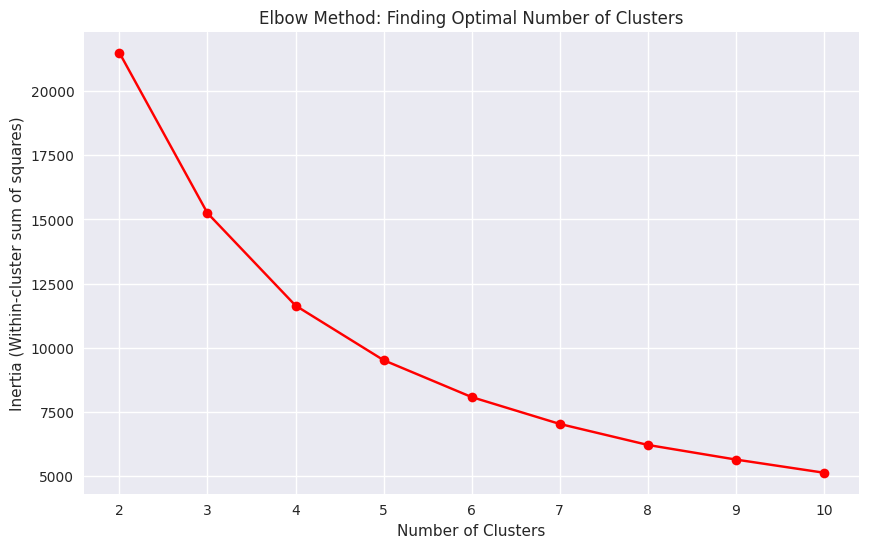

In [56]:
# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertias, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method: Finding Optimal Number of Clusters')
plt.grid(True)
plt.show()

In [50]:
# Select the best model (Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_supervised, y_train_supervised)
y_pred_best = best_model.predict(X_test_supervised)

## Summary and Insights

### What We Accomplished:

1. **Unsupervised Learning (K-Means)**: Grouped California houses into 6 clusters based on location and income
2. **Supervised Learning**: Trained classification models to predict cluster membership
3. **Model Performance**: Random Forest achieved 99.52% accuracy in predicting cluster assignments
4. **Geographic Patterns**: Clusters show clear geographic separation across California

### Key Findings:

- **Geographic clustering works well**: Houses are naturally grouped by location
- **Income patterns**: Median income adds valuable information for clustering
- **Model Performance**: Very high accuracy, but may indicate overfitting due to oversegmentation
- **Feature importance**: All three features (Latitude, Longitude, MedInc) contribute to cluster prediction

### **Important Caveat:**
The 6-cluster choice may be oversegmented for this geographic data. The very high supervised accuracy (99.52%) should be interpreted cautiously as it might indicate the model is memorizing arbitrary boundaries rather than learning meaningful patterns.

This workflow demonstrates how unsupervised learning can create labels for subsequent supervised learning tasks, though proper validation is crucial to ensure meaningful results.

In [54]:
# Silhouette score for 6 clusters
silhouette_avg = silhouette_score(X_train_scaled, train_clusters)
silhouette_avg

0.39873655111734757

In [55]:
# Define range of cluster numbers to test
cluster_range = range(2, 11)

# Elbow method to find optimal number of clusters
inertias = []

for n_clusters in cluster_range:
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_scaled)
    inertias.append(kmeans_temp.inertia_)

#### **Analysis: Is 6 clusters optimal?**

**Based on the results above:**

- **Silhouette Score Winner**: 2 clusters (0.5473) - "Good" clustering
- **Second Best**: 3 clusters (0.5154) - Still "Good" clustering  
- **6 clusters**: 0.3987 - Only "Moderate" clustering

**Conclusion: 2-3 clusters are optimal, not 6!**

Let's visualize what 2 and 3 clusters look like:

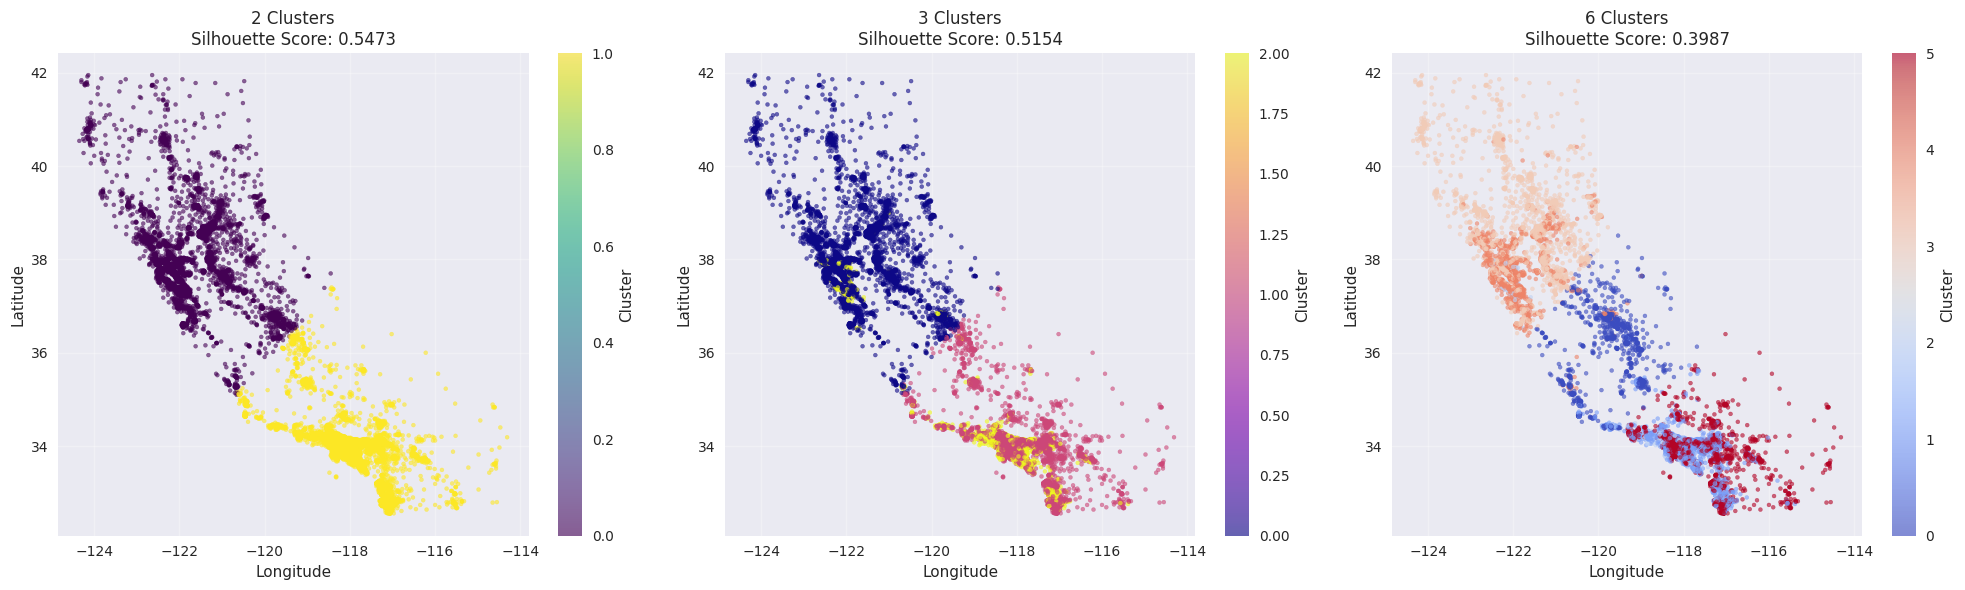

In [58]:
# Compare 2, 3, and 6 clusters visually
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cluster_options = [2, 3, 6]
colors = ['viridis', 'plasma', 'coolwarm']

for i, (n_clusters, cmap) in enumerate(zip(cluster_options, colors)):
    # Train K-means with different cluster numbers
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    temp_labels = kmeans_temp.fit_predict(X_train_scaled)
    
    # Calculate silhouette score
    temp_silhouette = silhouette_score(X_train_scaled, temp_labels)
    
    # Create temporary dataframe for plotting
    temp_df = X_train.copy()
    temp_df['cluster'] = temp_labels
    
    # Plot
    scatter = axes[i].scatter(temp_df['Longitude'], temp_df['Latitude'], 
                             c=temp_df['cluster'], cmap=cmap, alpha=0.6, s=8)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{n_clusters} Clusters\nSilhouette Score: {temp_silhouette:.4f}')
    axes[i].grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=axes[i], label='Cluster')

plt.tight_layout()
plt.show()

### **Critical Insight: High Supervised Accuracy ≠ Meaningful Clusters**

**Important realization**: The supervised model achieved 99.52% accuracy predicting 6 clusters, but this **does NOT** mean the 6 clusters are meaningful!

## Model Persistence

Let's save both the K-means model and the best supervised model for future use:

In [ ]:
# Create the K_means directory if it doesn't exist
os.makedirs('../models/K_means', exist_ok=True)

# Save the K-means model
with open('../models/K_means/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save the scaler (needed for predictions)
with open('../models/K_means/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the best supervised model (Random Forest)
with open('../models/K_means/best_supervised_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)